<div style="border:solid green 2px; padding: 20px">

<b>Привет, Влад! Поздравляю с выполнением очередного проекта!</b>

Меня зовут Петр Раздобреев и я буду проверять твою работу. Попробую помочь сделать тебе её еще лучше! В Практикуме принято общени на ты, но если это дискомфортно, то сообщи об этом)

Ниже ты найдешь мои комментарии - пожалуйста, не перемещай, не изменяй и не удаляй их. Я буду использовать цветовую разметку:

<div class="alert alert-danger">
<b>Комментарий ревьюера:</b>☁️Так выделены самые важные замечания. Без их отработки проект не будет принят. </div>

<div class="alert alert-warning">
<b>Комментарий ревьюера:</b>⛅️ Так выделены небольшие замечания.Такие замечания в проекте допустимы, это пространство для улучшений в будущем.
</div>

<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️Так я выделяю успешные идеи.</div>

Давай работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комменатри — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии:
<div class="alert alert-info"> <b>Комментарий студента:</b> Например, вот так.</div>

Всё это поможет выполнить повторную проверку твоего проекта оперативнее.
    

<div style="border:solid green 2px; padding: 20px">  <b>Описание проекта:</b>

Наша компания предлагает пользователям своё развлекательное приложение Procrastinate Pro+.
Несмотря на огромные вложения в рекламу, последние несколько месяцев компания терпит убытки. Наша задача — разобраться в причинах и помочь компании выйти в плюс.
    
Есть данные о пользователях, привлечённых с 1 мая по 27 октября 2019 года: лог сервера с данными об их посещениях, выгрузка их покупок за этот период, рекламные расходы.
    
Нам предстоит изучить: 1) откуда приходят пользователи и какими устройствами они пользуются; 2) сколько стоит привлечение пользователей из различных рекламных каналов; 3) сколько денег приносит каждый клиент; 4) когда расходы на привлечение клиента окупаются; 5) какие факторы мешают привлечению клиентов.
</div>

<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
    
Благодарю за вступление) </div>

## Загрузка данных и предобработка

**Пути к файлам**

- визиты: `/datasets/visits_info_short.csv`. [Скачать датасет](https://code.s3.yandex.net/datasets/visits_info_short.csv);
- заказы: `/datasets/orders_info_short.csv`. [Скачать датасет](https://code.s3.yandex.net/datasets/orders_info_short.csv);
- расходы: `/datasets/costs_info_short.csv`. [Скачать датасет](https://code.s3.yandex.net/datasets/costs_info_short.csv).

### Общая информация о таблицах

In [ ]:
#импортируем библиотеки:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from matplotlib import pyplot as plt

In [ ]:
#сохраняем таблицы в переменные:
visits = pd.read_csv('/datasets/visits_info_short.csv') # журнал сессий
orders = pd.read_csv('/datasets/orders_info_short.csv')  # покупки
costs = pd.read_csv('/datasets/costs_info_short.csv') # траты на рекламу
events =  None

<div class="alert alert-info"> Написала функцию для первичного анализа датафреймов</div>

<div class="alert alert-warning">
<b>Комментарий ревьюера v2:</b>⛅️

Замечательно, только можно специально не создавать переменные для присваивания им значений, можно просто выводить эти значения
    
</div>

In [ ]:
#зададим функцию для отображения основной информации по датафрейму:
def notion(df):
    v = display(df.head()),
    i = df.info()
    return v, i

In [ ]:
#Изучим таблицы на наличие пропусков, некорректных типов данных:
#журнал сессий
notion(visits)

,User Id,Region,Device,Channel,Session Start,Session End
0,981449118918,United States,iPhone,organic,2019-05-01 02:36:01,2019-05-01 02:45:01
1,278965908054,United States,iPhone,organic,2019-05-01 04:46:31,2019-05-01 04:47:35
2,590706206550,United States,Mac,organic,2019-05-01 14:09:25,2019-05-01 15:32:08
3,326433527971,United States,Android,TipTop,2019-05-01 00:29:59,2019-05-01 00:54:25
4,349773784594,United States,Mac,organic,2019-05-01 03:33:35,2019-05-01 03:57:40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   User Id        309901 non-null  int64 
 1   Region         309901 non-null  object
 2   Device         309901 non-null  object
 3   Channel        309901 non-null  object
 4   Session Start  309901 non-null  object
 5   Session End    309901 non-null  object
dtypes: int64(1), object(5)
memory usage: 14.2+ MB


((None,), None)

In [ ]:
#таблица с данными о покупках:
notion(orders)

,User Id,Event Dt,Revenue
0,188246423999,2019-05-01 23:09:52,4.99
1,174361394180,2019-05-01 12:24:04,4.99
2,529610067795,2019-05-01 11:34:04,4.99
3,319939546352,2019-05-01 15:34:40,4.99
4,366000285810,2019-05-01 13:59:51,4.99


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User Id   40212 non-null  int64  
 1   Event Dt  40212 non-null  object 
 2   Revenue   40212 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 942.6+ KB


((None,), None)

In [ ]:
#таблица с данными о тратах на рекламу:
notion(costs)

,dt,Channel,costs
0,2019-05-01,FaceBoom,113.3
1,2019-05-02,FaceBoom,78.1
2,2019-05-03,FaceBoom,85.8
3,2019-05-04,FaceBoom,136.4
4,2019-05-05,FaceBoom,122.1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       1800 non-null   object 
 1   Channel  1800 non-null   object 
 2   costs    1800 non-null   float64
dtypes: float64(1), object(2)
memory usage: 42.3+ KB


((None,), None)

<div class="alert alert-info"> <b>Вывод</b>: пропусков в данных нет, необходимо только <b>переименовать заголовки</b> и <b>изменить типы данных</b> в таблицах visits, orders, costs по столбцам, хранящих данные о времени c object на datetime
</div>


### Предобработка и поиск дубликатов

In [ ]:
#преобразуем заголовки столбцов к единому виду:

visits.columns =  [x.lower().replace(' ', '_') for x in visits.columns] #visits.columns.str.lower()
orders.columns = [y.lower().replace(' ', '_') for y in orders.columns] #orders.columns.str.lower()
costs.columns = costs.columns.str.lower()

<div class="alert alert-warning">
<b>Комментарий ревьюера:</b>⛅️
    
* Проблема названий столбцов ведь только в том, что имеются пробелы и заглавные буквы, соответственно можно было бы обойтись и без `rename`
* Могу предложить такой вариант `visits.columns = [x.lower().replace(' ', '_') for x in visits.columns]`
    


In [ ]:
# преобразуем данные о времени:
visits['session_start'] = pd.to_datetime(visits['session_start'])
visits['session_end'] = pd.to_datetime(visits['session_end'])
orders['event_dt'] = pd.to_datetime(orders['event_dt'])
costs['dt'] = pd.to_datetime(costs['dt']).dt.date

<div class="alert alert-info"> <b>Проверим таблицы на наличие явных и неявных дубликатов:</b> </div>

In [ ]:
#Изучим уникальные значения в столбцх с не числовыми данными и устраним неявные дубликаты, если они есть:
visits['channel'].sort_values().unique()

array(['AdNonSense', 'FaceBoom', 'LeapBob', 'MediaTornado',
       'OppleCreativeMedia', 'RocketSuperAds', 'TipTop', 'WahooNetBanner',
       'YRabbit', 'lambdaMediaAds', 'organic'], dtype=object)

In [ ]:
costs['channel'].sort_values().unique()

array(['AdNonSense', 'FaceBoom', 'LeapBob', 'MediaTornado',
       'OppleCreativeMedia', 'RocketSuperAds', 'TipTop', 'WahooNetBanner',
       'YRabbit', 'lambdaMediaAds'], dtype=object)

In [ ]:
visits['device'].sort_values().unique()

array(['Android', 'Mac', 'PC', 'iPhone'], dtype=object)

In [ ]:
visits['region'].sort_values().unique()

array(['France', 'Germany', 'UK', 'United States'], dtype=object)

In [ ]:
#Проверим, есть ли явные дубликаты:
vd = visits.duplicated().sum()
od = orders.duplicated().sum()
cd = costs.duplicated().sum()

display(f'Количество явных дубликтов visits: {vd}')
display(f'Количество явных дубликтов orders: {od}')
display(f'Количество явных дубликтов costs: {cd}')

'Количество явных дубликтов visits: 0'

'Количество явных дубликтов orders: 0'

'Количество явных дубликтов costs: 0'

<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
    
Ты многократно писала очень схожие куски кода, но можно ведь сделать функции для первичного анализа датафреймов, смотреть распределение численных значений при помощи `describe`, анализировать какие строки наиболее частые при помощи `value_counts`, ну и `head` с `info` в эту же функцию первичного анализа стоит поместить, и при помощи нее можно получать первоначальную информацию о каждом датасете по вызову функции к каждому новому датасету, ну и такую функцию переносить из проекта в проект, чтобы максимально упрощать себе первичный анализ и оставлять больше сил и времени на исследования).
    
Безусловно в этом проекте нет необходимости в глубоком анализе данных, но например можно добавить переименование столбцов в неё
</div>

<div class="alert alert-info"> <b>Вывод</b>: Предобработка завершена. Пропусков в данных нет, тип данных соответствует, явные и неявные дубликаты отсутствуют.</div>

## Функции для расчёта и анализа LTV, ROI, удержания и конверсии.

In [ ]:
# функция для создания пользовательских профилей

def get_profiles(sessions, orders, events, ad_costs, event_names=[]):

    # находим параметры первых посещений
    profiles = (
        sessions.sort_values(by=['user_id', 'session_start'])
        .groupby('user_id')
        .agg(
            {
                'session_start': 'first',
                'channel': 'first',
                'device': 'first',
                'region': 'first',
            }
        )
        .rename(columns={'session_start': 'first_ts'})
        .reset_index()
    )

    # для когортного анализа определяем дату первого посещения
    # и первый день месяца, в который это посещение произошло
    profiles['dt'] = profiles['first_ts'].dt.date
    profiles['month'] = profiles['first_ts'].astype('datetime64[M]')

    # добавляем признак платящих пользователей
    profiles['payer'] = profiles['user_id'].isin(orders['user_id'].unique())

    # добавляем флаги для всех событий из event_names
    for event in event_names:
        if event in events['event_name'].unique():
            profiles[event] = profiles['user_id'].isin(
                events.query('event_name == @event')['user_id'].unique()
            )

    # считаем количество уникальных пользователей
    # с одинаковыми источником и датой привлечения
    new_users = (
        profiles.groupby(['dt', 'channel'])
        .agg({'user_id': 'nunique'})
        .rename(columns={'user_id': 'unique_users'})
        .reset_index()
    )

    # объединяем траты на рекламу и число привлечённых пользователей
    ad_costs = ad_costs.merge(new_users, on=['dt', 'channel'], how='left')

    # делим рекламные расходы на число привлечённых пользователей
    ad_costs['acquisition_cost'] = ad_costs['costs'] / ad_costs['unique_users']

    # добавляем стоимость привлечения в профили
    profiles = profiles.merge(
        ad_costs[['dt', 'channel', 'acquisition_cost']],
        on=['dt', 'channel'],
        how='left',
    )

    # стоимость привлечения органических пользователей равна нулю
    profiles['acquisition_cost'] = profiles['acquisition_cost'].fillna(0)

    return profiles

In [ ]:
# функция для расчёта удержания

def get_retention(
    profiles,
    sessions,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # добавляем столбец payer в передаваемый dimensions список
    dimensions = ['payer'] + dimensions

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # собираем «сырые» данные для расчёта удержания
    result_raw = result_raw.merge(
        sessions[['user_id', 'session_start']], on='user_id', how='left'
    )
    result_raw['lifetime'] = (
        result_raw['session_start'] - result_raw['first_ts']
    ).dt.days

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу удержания
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # получаем таблицу динамики удержания
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time

In [ ]:

# функция для расчёта конверсии

def get_conversion(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # определяем дату и время первой покупки для каждого пользователя
    first_purchases = (
        purchases.sort_values(by=['user_id', 'event_dt'])
        .groupby('user_id')
        .agg({'event_dt': 'first'})
        .reset_index()
    )

    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        first_purchases[['user_id', 'event_dt']], on='user_id', how='left'
    )

    # рассчитываем лайфтайм для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days

    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        result = result.fillna(0).cumsum(axis = 1)
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # делим каждую «ячейку» в строке на размер когорты
        # и получаем conversion rate
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу конверсии
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # для таблицы динамики конверсии убираем 'cohort' из dimensions
    if 'cohort' in dimensions:
        dimensions = []

    # получаем таблицу динамики конверсии
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time

In [ ]:
# функция для расчёта LTV и ROI

def get_ltv(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')
    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        purchases[['user_id', 'event_dt', 'revenue']], on='user_id', how='left'
    )
    # рассчитываем лайфтайм пользователя для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days
    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']

    # функция группировки по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        # строим «треугольную» таблицу выручки
        result = df.pivot_table(
            index=dims, columns='lifetime', values='revenue', aggfunc='sum'
        )
        # находим сумму выручки с накоплением
        result = result.fillna(0).cumsum(axis=1)
        # вычисляем размеры когорт
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        # объединяем размеры когорт и таблицу выручки
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # считаем LTV: делим каждую «ячейку» в строке на размер когорты
        result = result.div(result['cohort_size'], axis=0)
        # исключаем все лайфтаймы, превышающие горизонт анализа
        result = result[['cohort_size'] + list(range(horizon_days))]
        # восстанавливаем размеры когорт
        result['cohort_size'] = cohort_sizes

        # собираем датафрейм с данными пользователей и значениями CAC,
        # добавляя параметры из dimensions
        cac = df[['user_id', 'acquisition_cost'] + dims].drop_duplicates()

        # считаем средний CAC по параметрам из dimensions
        cac = (
            cac.groupby(dims)
            .agg({'acquisition_cost': 'mean'})
            .rename(columns={'acquisition_cost': 'cac'})
        )

        # считаем ROI: делим LTV на CAC
        roi = result.div(cac['cac'], axis=0)

        # удаляем строки с бесконечным ROI
        roi = roi[~roi['cohort_size'].isin([np.inf])]

        # восстанавливаем размеры когорт в таблице ROI
        roi['cohort_size'] = cohort_sizes

        # добавляем CAC в таблицу ROI
        roi['cac'] = cac['cac']

        # в финальной таблице оставляем размеры когорт, CAC
        # и ROI в лайфтаймы, не превышающие горизонт анализа
        roi = roi[['cohort_size', 'cac'] + list(range(horizon_days))]

        # возвращаем таблицы LTV и ROI
        return result, roi

    # получаем таблицы LTV и ROI
    result_grouped, roi_grouped = group_by_dimensions(
        result_raw, dimensions, horizon_days
    )

    # для таблиц динамики убираем 'cohort' из dimensions
    if 'cohort' in dimensions:
        dimensions = []

    # получаем таблицы динамики LTV и ROI
    result_in_time, roi_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    return (
        result_raw,  # сырые данные
        result_grouped,  # таблица LTV
        result_in_time,  # таблица динамики LTV
        roi_grouped,  # таблица ROI
        roi_in_time,  # таблица динамики ROI
    )

<div style="border:solid green 2px; padding: 20px"><b> Функции визуализации удержания, конверсии, LTV и ROI</b></div>

In [ ]:
# функция для сглаживания фрейма

def filter_data(df, window):
    # для каждого столбца применяем скользящее среднее
    for column in df.columns.values:
        df[column] = df[column].rolling(window).mean()
    return df

In [ ]:
# функция для визуализации удержания

def plot_retention(retention, retention_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 10))

    # исключаем размеры когорт и удержание первого дня
    retention = retention.drop(columns=['cohort_size', 0])
    # в таблице динамики оставляем только нужный лайфтайм
    retention_history = retention_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # если в индексах таблицы удержания только payer,
    # добавляем второй признак — cohort
    if retention.index.nlevels == 1:
        retention['cohort'] = 'All users'
        retention = retention.reset_index().set_index(['cohort', 'payer'])

    # в таблице графиков — два столбца и две строки, четыре ячейки
    # в первой строим кривые удержания платящих пользователей
    ax1 = plt.subplot(2, 2, 1)
    retention.query('payer == True').droplevel('payer').T.plot(
        grid=True, ax=ax1
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание платящих пользователей')

    # во второй ячейке строим кривые удержания неплатящих
    # вертикальная ось — от графика из первой ячейки
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    retention.query('payer == False').droplevel('payer').T.plot(
        grid=True, ax=ax2
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание неплатящих пользователей')

    # в третьей ячейке — динамика удержания платящих
    ax3 = plt.subplot(2, 2, 3)
    # получаем названия столбцов для сводной таблицы
    columns = [
        name
        for name in retention_history.index.names
        if name not in ['dt', 'payer']
    ]
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == True').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания платящих пользователей на {}-й день'.format(
            horizon
        )
    )

    # в чётвертой ячейке — динамика удержания неплатящих
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == False').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax4)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания неплатящих пользователей на {}-й день'.format(
            horizon
        )
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# функция для визуализации конверсии

def plot_conversion(conversion, conversion_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 5))

    # исключаем размеры когорт
    conversion = conversion.drop(columns=['cohort_size'])
    # в таблице динамики оставляем только нужный лайфтайм
    conversion_history = conversion_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # первый график — кривые конверсии
    ax1 = plt.subplot(1, 2, 1)
    conversion.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Конверсия пользователей')

    # второй график — динамика конверсии
    ax2 = plt.subplot(1, 2, 2, sharey=ax1)
    columns = [
        # столбцами сводной таблицы станут все столбцы индекса, кроме даты
        name for name in conversion_history.index.names if name not in ['dt']
    ]
    filtered_data = conversion_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика конверсии пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show()

In [ ]:
# функция для визуализации LTV и ROI

def plot_ltv_roi(ltv, ltv_history, roi, roi_history, horizon, window=7):

    # задаём сетку отрисовки графиков
    plt.figure(figsize=(20, 10))

    # из таблицы ltv исключаем размеры когорт
    ltv = ltv.drop(columns=['cohort_size'])
    # в таблице динамики ltv оставляем только нужный лайфтайм
    ltv_history = ltv_history.drop(columns=['cohort_size'])[[horizon - 1]]

    # стоимость привлечения запишем в отдельный фрейм
    cac_history = roi_history[['cac']]

    # из таблицы roi исключаем размеры когорт и cac
    roi = roi.drop(columns=['cohort_size', 'cac'])
    # в таблице динамики roi оставляем только нужный лайфтайм
    roi_history = roi_history.drop(columns=['cohort_size', 'cac'])[
        [horizon - 1]
    ]

    # первый график — кривые ltv
    ax1 = plt.subplot(2, 3, 1)
    ltv.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('LTV')

    # второй график — динамика ltv
    ax2 = plt.subplot(2, 3, 2, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in ltv_history.index.names if name not in ['dt']]
    filtered_data = ltv_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика LTV пользователей на {}-й день'.format(horizon))

    # третий график — динамика cac
    ax3 = plt.subplot(2, 3, 3, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in cac_history.index.names if name not in ['dt']]
    filtered_data = cac_history.pivot_table(
        index='dt', columns=columns, values='cac', aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика стоимости привлечения пользователей')

    # четвёртый график — кривые roi
    ax4 = plt.subplot(2, 3, 4)
    roi.T.plot(grid=True, ax=ax4)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('ROI')

    # пятый график — динамика roi
    ax5 = plt.subplot(2, 3, 5, sharey=ax4)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in roi_history.index.names if name not in ['dt']]
    filtered_data = roi_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax5)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.xlabel('Дата привлечения')
    plt.title('Динамика ROI пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show()

<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
        
Все необходимые функции были заданы, можно приступать к анализу. В принципе можно было добавить `markdown` заголовков, чтобы разграничить функции и упростить поиск нужной

</div>

## Исследовательский анализ данных

<div class="alert alert-info"> В рамках проводимого исследования нам необходимо выяснить:
   
1) Пользователи из каких стран приходят в наше приложение? Сколько пользователей по каждой стране? У какой страны наибольшая доля среди пользователей, совершающих покупки?

2) Какими устройствами пользуются наши клиенты? Какие устройства предпочитают платящие клиенты?

3) Благодяря каким рекламным источникам привлечения пользователи переходят в наше приложение? Какие каналы привлекли больше всего платящих пользователей?
    
Для ответа на поставленные вопросы построим сводные таблицы, в которых отразим количество пользователей и долю платящих для каждой группировки. </div>


In [ ]:
# Для начала составим профили пользователей:
profiles = get_profiles(visits, orders, events, costs)
profiles.head()

,user_id,first_ts,channel,device,region,dt,month,payer,acquisition_cost
0,599326,2019-05-07 20:58:57,FaceBoom,Mac,United States,2019-05-07,2019-05-01,True,1.088172
1,4919697,2019-07-09 12:46:07,FaceBoom,iPhone,United States,2019-07-09,2019-07-01,False,1.107237
2,6085896,2019-10-01 09:58:33,organic,iPhone,France,2019-10-01,2019-10-01,False,0.000000
3,22593348,2019-08-22 21:35:48,AdNonSense,PC,Germany,2019-08-22,2019-08-01,False,0.988235
4,31989216,2019-10-02 00:07:44,YRabbit,iPhone,United States,2019-10-02,2019-10-01,False,0.230769


In [ ]:
# Определим минимальную и максимальную даты привлечения пользователей для проверки:
min_analysis_date = profiles['dt'].min()
min_analysis_date

datetime.date(2019, 5, 1)

In [ ]:
max_analysis_date  = profiles['dt'].max()
max_analysis_date

datetime.date(2019, 10, 27)

<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
    
Отлично, маленький спойлер и в жизни и даже в проектах Практикума не всегда описание временного интервала будет совпадать с реальными данными, поэтому лучше интервал всегда проверять)
</div>

<div style="border:solid green 2px; padding: 20px">  <b>Note: Максимальная дата совпала с указанной в ТЗ</b> </div>

### Доля платящих пользователей по каждой стране

In [ ]:
#Построим таблицу, отражающую количество пользователей и долю платящих из каждой страны
#для удобства напишем функцию, которая сгруппирует данные по нужному столбцу:

def profiles_payers(c):
    profiles_payers = profiles.groupby(c).agg({'user_id': 'nunique', 'payer': 'mean'}).sort_values(
        by='payer', ascending=False).rename(columns={'user_id':'Общее кол-во пользователей', 'payer':'Конверсия'})
    profiles_payers['Кол-во платящих пользователей'] = profiles_payers['Общее кол-во пользователей'] * profiles_payers['Конверсия']
    profiles_payers['Доля платящих'] = profiles_payers['Кол-во платящих пользователей']/sum(profiles_payers['Кол-во платящих пользователей'])
    #profiles_payers.sort_values(by='Доля платящих', ascending=False)
    return profiles_payers

p1 = profiles_payers('region')
p1.sort_values(by='Доля платящих', ascending=False).style.format(
    {'Доля платящих':'{:.2f}', 'Конверсия':'{:.2f}', 'Кол-во платящих пользователей':'{:.0f}'}).highlight_max(
    color='yellowgreen').highlight_min(color='coral')

,Общее кол-во пользователей,Конверсия,Кол-во платящих пользователей,Доля платящих
region,,,,
United States,100002,0.07,6902,0.78
UK,17575,0.04,700,0.08
France,17450,0.04,663,0.07
Germany,14981,0.04,616,0.07


<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
    
    
* Старайся округлять числа, чтобы у них не было таких длинных хвостов, есть любопытный способ, который позволяет облагородить вывод в частности и дробей - `style.format`, начать читать про него можно [тут]('https://habr.com/ru/post/521894/')

* Прекрасная идея автоматизировать повторяющиеся задачи

</div>

In [ ]:
#добавим столбец "рынок" для дополнительной агрегации не по странам, а по рынкам - европейскому и американскому
#будет использоваться далее
def categorize(category):
    if category == 'United States':
        return 'США'
    else:
        return 'Европа'

In [ ]:
profiles['market'] = profiles['region'].apply(categorize)

<div class="alert alert-info"> <b>Вывод</b>: пользователи приходят к нам из США, Великобритании, Франции и Германии. Больше всего платящих пользователей приходится на США. В целом американский рынок можно назвать интереснее европейского - 77.7% платящих пользователей приходится на США, 22.3% - на страны Европы. У пользователей из США выше конверсия - переход от обычного пользователя в платящего - 7% против примерно 4% у любой из европейских стран. </div>

### Доля платящих пользователей по каждому устройству

In [ ]:
#Постройте таблицу, отражающую количество пользователей и долю платящих для каждого устройства
p2 = profiles_payers('device')
p2.sort_values(by='Доля платящих', ascending=False).style.format(
    {'Доля платящих':'{:.2f}', 'Конверсия':'{:.2f}', 'Кол-во платящих пользователей':'{:.0f}'}).highlight_max(
    color='yellowgreen').highlight_min(color='coral')

,Общее кол-во пользователей,Конверсия,Кол-во платящих пользователей,Доля платящих
device,,,,
iPhone,54479,0.06,3382,0.38
Android,35032,0.06,2050,0.23
Mac,30042,0.06,1912,0.22
PC,30455,0.05,1537,0.17


In [ ]:
#Дополнительно проверим, какие устройства предпочитают в разных странах:

profiles_dr = profiles.groupby(['device', 'region']).agg({'user_id':'nunique', 'payer': 'mean'}).rename(
    columns={'user_id':'Общее кол-во пользователей', 'payer':'Конверсия'})
profiles_dr['Кол-во платящих пользователей'] = profiles_dr['Общее кол-во пользователей'] * profiles_dr['Конверсия']
profiles_dr['Доля платящих'] = profiles_dr['Кол-во платящих пользователей']/sum(profiles_dr['Кол-во платящих пользователей'])
profiles_dr.style.format('{:.3f}').highlight_max(
    color='yellowgreen').highlight_min(color='coral')

<div class="alert alert-info"> <b>Вывод</b>: Пользователи нашего приложения используют его на следующих устройствах: Mac, IPhone, Android и PC. Платящие пользователи предпочитают IPhone - 38%. Конверсия у устройств в районе 5-6%, на верхней границе располагаются устройства системы iOS - Mac и IPhone, хуже всего конверсия у пользователей с PC 5%/

Стоит отметить также, что в разрезе стран/рынков, клиенты которые платят - это пользователи PC на европейском рынке (доля платящих пользователей - 9 %) и пользователи IPhone на американском - 34%. Меньше всего платящих пользователей с устройствами Mac из Германии - их менее 1% (в совокупности по европе у Mac тоже минимум - 2% платящих пользователей)
</div>

### Доля платящих пользователей по каждому рекламному каналу

In [ ]:
p3 = profiles_payers('channel')
p3.sort_values(by='Доля платящих', ascending=False).style.format('{:.3f}').highlight_max(
    color='yellowgreen').highlight_min(color='coral')

,Общее кол-во пользователей,Конверсия,Кол-во платящих пользователей,Доля платящих
channel,,,,
FaceBoom,29144.000,0.122,3557.000,0.401
TipTop,19561.000,0.096,1878.000,0.211
organic,56439.000,0.021,1160.000,0.131
WahooNetBanner,8553.000,0.053,453.000,0.051
AdNonSense,3880.000,0.113,440.000,0.050
RocketSuperAds,4448.000,0.079,352.000,0.040
LeapBob,8553.000,0.031,262.000,0.030
OppleCreativeMedia,8605.000,0.027,233.000,0.026
lambdaMediaAds,2149.000,0.105,225.000,0.025


<a id="i"></a> Разбивка по странам и каналам

In [ ]:
#Добавим группировку по региону - Американский рынок
profiles_cr = profiles.query('region == "United States"').groupby('channel').agg({'user_id':'nunique', 'payer': 'mean'}).rename(
    columns={'user_id':'Общее кол-во пользователей', 'payer':'Конверсия'})
profiles_cr['Кол-во платящих пользователей'] = profiles_cr['Общее кол-во пользователей'] * profiles_cr['Конверсия']
profiles_cr['Доля платящих'] = profiles_cr['Кол-во платящих пользователей']/sum(profiles_cr['Кол-во платящих пользователей'])
profiles_cr.sort_values(by='Доля платящих', ascending=False).style.format(
    '{:.2f}').highlight_max(color='yellowgreen').highlight_min(color='coral')

,Общее кол-во пользователей,Конверсия,Кол-во платящих пользователей,Доля платящих
channel,,,,
FaceBoom,29144.00,0.12,3557.00,0.52
TipTop,19561.00,0.10,1878.00,0.27
organic,38173.00,0.02,794.00,0.12
RocketSuperAds,4448.00,0.08,352.00,0.05
YRabbit,4312.00,0.04,165.00,0.02
MediaTornado,4364.00,0.04,156.00,0.02


In [ ]:
#Добавим группировку по региону - Европейский рынок
profiles_cr = profiles.query('region != "United States"').groupby(['channel', 'region']).agg({'user_id':'nunique', 'payer': 'mean'}).rename(
    columns={'user_id':'Общее кол-во пользователей', 'payer':'Конверсия'})
profiles_cr['Кол-во платящих пользователей'] = profiles_cr['Общее кол-во пользователей'] * profiles_cr['Конверсия']
profiles_cr['Доля платящих'] = profiles_cr['Кол-во платящих пользователей']/sum(profiles_cr['Кол-во платящих пользователей'])
profiles_cr.sort_values(by='Доля платящих', ascending=False).style.format(
    '{:.3f}').highlight_max(color='yellowgreen').highlight_min(color='coral')

<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
    
Вот здесь бы очень ценным было разбиение каналов по странам, удалось бы определённые закономерности выявить)

<div class="alert alert-info"> <b>Комментарий студента</b>: Добавила.
       
По Америке стало понятно, что канал на который мы больше денег потратили в 2 раза меньше платящих пользователей привёл, но это уже постфактум, когда я уже видела график затрат на рекламу.

Также видно каналы, которые приводят меньше платящих пользователей, чем по organic.
А какие ещё есть закономерности?
    
<b>Вопрос:</b>
Увидела что по европейскому рынку лучше приходят платящие пользователи через WahooNetBanner, а из аутсайдеров -  lambdaMediaAds, хотя он по ltv лидер и третий по конверсии - что меня смутило - рекомендовать ли его в итоге или нет?

</div>

<div class="alert alert-success">
<b>Комментарий ревьюера v2:</b>☀️
   
В этом проекте было бы любопытным вообще построить разбивку каналов по странам, удалось бы обнаружить интересное. Лучше рекомендовал по итогам всего исследования пример - `FaceBoom`, высокий процент платящих, но удержание ужасное и как итог скверная окупаемость

</div>

<div class="alert alert-info"> <b>Вывод</b>: Больше всего платящих пользователей приходит с каналов FaceBoom, TipTop и organic; среди всех каналов большей долей обладает FaceBoom - 40% всех платящих пользователей составляют клиенты пришедшие через этот рекламный источник. TipTop - 21% платящих пользователей,  organic - 13%. Аутсайдеры - MediaTornado (1,8%),	YRabbit (1,9 %), lambdaMediaAds (2,5%).

При дополнительной группировке по странам выясняется, что:
    с американского рынка 52% платящих пользователей приходит через канал FaceBoom, 27% через TipTop, аутсайдеры MediaTornado и YRabbiе по 2%;
    с европейского рынка максимум пользователей - 7,5 - 7,7% - приходят через канал WahooNetBanner, на втором месте AdNonSense (7,2-7,6%). Аутсайдерами являются OppleCreativeMedia	и lambdaMediaAds.
</div>

<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
    
От органики так мало платящих, так как зачастую закупочные каналы оптимизируются с целью приведения максимально платящей аудитории, а органические пользователи случаются разные</div>

## Маркетинг

<div class="alert alert-info">  Для того, чтобы понять, где конкретно могла возникнуть проблема, <b>выясним, на что ушли рекламные деньги</b>. Для начала определим общую сумму расходов на маркетинг, далее рассмотрим, как распределялись расходы по рекламным источникам, как менялись расходы на протяжении исследуемого временного промежутка. Важно также выяснить, сколько в среднем стоило компании привлечение одного пользователя (CAC) по каждому рекламному источнику.</div>

### Распределение расходов на рекламу

In [ ]:
#Определим общую сумму расходов на маркетинг:
total_costs = costs['costs'].sum()
round(total_costs, 2)

105497.3

In [ ]:
channel_costs = costs.pivot_table(index='channel', values='costs', aggfunc ='sum')

channel_costs['Доля в расходах на рекламу'] = channel_costs['costs']/total_costs
channel_costs.sort_values(by='Доля в расходах на рекламу', ascending=False)

,costs,Доля в расходах на рекламу
channel,,
TipTop,54751.30,0.518983
FaceBoom,32445.60,0.307549
WahooNetBanner,5151.00,0.048826
AdNonSense,3911.25,0.037074
OppleCreativeMedia,2151.25,0.020392
RocketSuperAds,1833.00,0.017375
LeapBob,1797.60,0.017039
lambdaMediaAds,1557.60,0.014764
MediaTornado,954.48,0.009047


<div class="alert alert-info"> <b>Вывод</b>: Всего на рекламу было потрачено 105,5 тыс у.е., из них 54,7 тыс у.е. потрачено на рекламу через канал TipTop, 32.4 тыс у.е. - на FaceBoom. В долевом соотношение на TipTop потрачено 52% от всех расходов на рекламу, на FaceBoom - 31%, на остальные рекламные источники - 17%  </div>

### Динамика изменения расходов  на рекламу (месяц, неделя)

In [ ]:
#Посмотрим динамику изменения расходов во времени (по неделям и месяцам) по каждому источнику
#создадим столбцы week и month
#costs.dtypes
costs['dt'] = pd.to_datetime(costs['dt']) #преобразуем в тип datetime
costs['week'] = costs['dt'].dt.isocalendar().week
costs['month'] = costs['dt'].astype('datetime64[M]')
costs.head()

,dt,channel,costs,week,month
0,2019-05-01,FaceBoom,113.3,18,2019-05-01
1,2019-05-02,FaceBoom,78.1,18,2019-05-01
2,2019-05-03,FaceBoom,85.8,18,2019-05-01
3,2019-05-04,FaceBoom,136.4,18,2019-05-01
4,2019-05-05,FaceBoom,122.1,18,2019-05-01


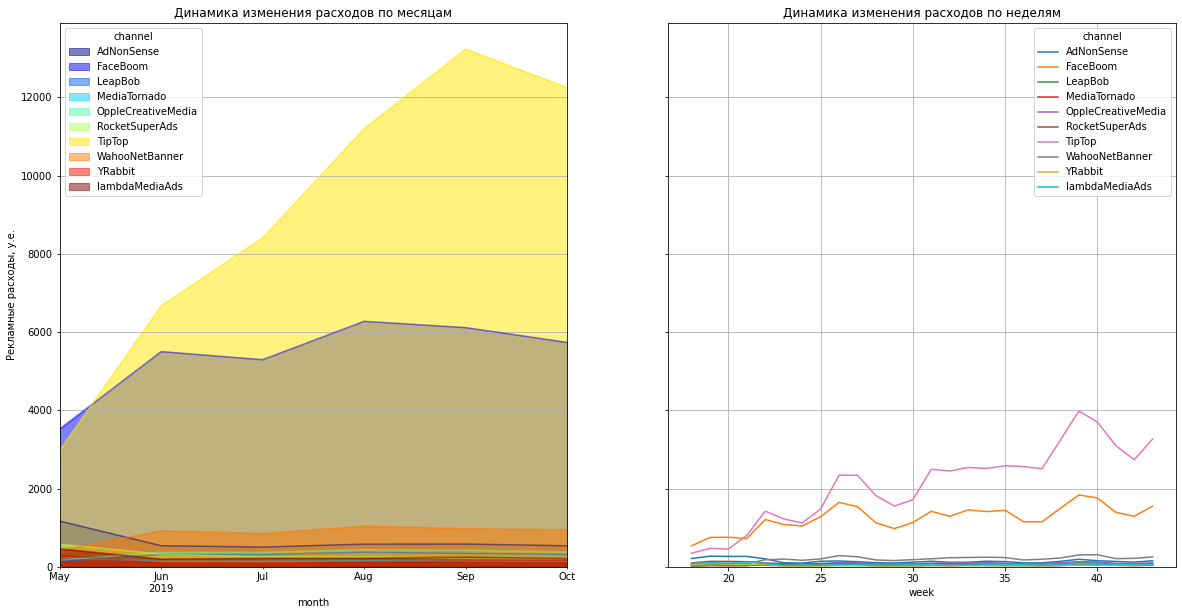

In [ ]:
#Построим диаграмму с областями

#по месяцам
plt.figure(figsize=(20, 10))
ax1= plt.subplot(1, 2, 1)
costs.pivot_table(index='month', columns='channel', values='costs', aggfunc='sum').plot.area(
    grid=True, stacked=False, cmap='jet', ax=ax1)
plt.title('Динамика изменения расходов по месяцам')
plt.ylabel('Рекламные расходы, у.е.')
#по неделям
ax2=plt.subplot(1, 2, 2, sharey=ax1)
costs.pivot_table(index='week', columns='channel', values='costs', aggfunc='sum').plot(grid=True, ax=ax2)#.area(
    #grid=True, stacked=False, ax=ax2)
plt.title('Динамика изменения расходов по неделям')
plt.show()

<a id="ii"></a>

<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
    
Для того, чтобы внимательнее изучить колебания затрат по каналам можно строить несколько графиков по размеру значений, здесь это не так критично, но вообще не особо понятно, как там дела с бюджетом всех каналов кроме двух крупнейших
</div>

<div class="alert alert-info"> <b>Вывод</b>: По каналу TipTop наращивание расходов произошло практически сразу - за первый месяц (мая) траты увеличились больше, чем в два раза. Пик расходов пришёлся на сентябрь-октябрь, в разрезе недель 37-43 недели, пик - 39 неделя. По сравнению с TipTop, динамика трат на рекламу по каналу FceBoom выглядит более стабильной, хотя и у неё рост произошёл примерно на 60%. Стоит отметить, что переломным моментом и началом тренда наращивания расходов стала 22 неделя. Здесь в рост пошли расходы по каналам TipTop (у него тренд начался чуть раньше - на 22 неделе), FaceBoom и даже WahooNetBanner (3-е место по объёму трат на рекламу). Расходы на AdNonSence, lambdaMediaAds и RocketSuperAds на 22 недели начали снижаться, но данные изменения по своим объёмам незначительны.   </div>

In [ ]:
#Определим, сколько в среднем стоило привлечение одного пользователя (CAC) из каждого источника:
#построим сводную таблицу с группировкой по каналам, значения CAC хранятся в столбце 'acquisition_cost'
avg_cac = profiles.pivot_table(
    index='channel', values='acquisition_cost', aggfunc = 'mean'
).sort_values(by='acquisition_cost', ascending=False).rename(columns={'acquisition_cost': 'cac'})
avg_cac.T

channel,TipTop,FaceBoom,AdNonSense,lambdaMediaAds,WahooNetBanner,RocketSuperAds,OppleCreativeMedia,YRabbit,MediaTornado,LeapBob,organic
cac,2.799003,1.113286,1.008054,0.724802,0.602245,0.412095,0.25,0.218975,0.218717,0.210172,0.0


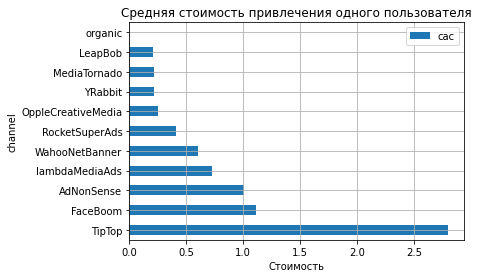

In [ ]:
avg_cac.plot(kind='barh', grid=True)
plt.title('Средняя стоимость привлечения одного пользователя')
plt.xlabel('Стоимость')
plt.show()

In [ ]:
#посмотрим на картину по рынкам:
profiles.pivot_table(
    index='channel', columns='market', values='acquisition_cost', aggfunc = 'mean')

market,Европа,США
channel,,
AdNonSense,1.008054,NaN
FaceBoom,NaN,1.113286
LeapBob,0.210172,NaN
MediaTornado,NaN,0.218717
OppleCreativeMedia,0.250000,NaN
RocketSuperAds,NaN,0.412095
TipTop,NaN,2.799003
WahooNetBanner,0.602245,NaN
YRabbit,NaN,0.218975


<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
    
Отличное построение, действительно мы видим явную региональную специфику каналов </div>

<div class="alert alert-info"> <b>Вывод</b>: Самым дорогим по стоимости привлечения клиентов оказался канал TipTop, где CAC = 2.8 у.е; привлечение клиентов через FaceBoom обходится компании в 1.1 у.е, через AdNonSense - в 1 у.е.

Самыми дешёвыми для компании каналами привлечения являются: YRabbit, MediaTornado и LeapBob. Стоимость привлечения клиента через них - 0.21-0.22 у.е.

В разрезе рынков становится понятно, что два самых дорогих канала TipTop и FaceBoom - это каналы привлечения пользователей из Америки. Третий по стоимости привлечения канал приводит европейских клиентов. </div>

## Оцените окупаемость рекламы

Для оценки окупаемости рекламы мы будем использовать графики LTV, ROI и CAC. В соответствии с ТЗ момент анализа - 1 ноября 2019 года, в бизнес-плане заложено, что пользователи должны окупаться не позднее чем через две недели после привлечения, следовательно максимальный горизонт планирования - 14 дней. Поскольку оценивать окупаемость рекламы для пользователей, пришедших напрямую (organic) не имеет смысла, исключим их из расчета LTV, ROI и CAC.



In [ ]:
#Установим момент и горизонт анализа  данных в соответствии с ТЗ
observation_date = datetime(2019, 11, 1).date()  # момент анализа
horizon_days = 14
profiles_no_org = profiles.query('channel ! = "organic"')#уберём канал 'organic', расходов по ним не было
profiles_no_org.channel.unique()

array(['FaceBoom', 'AdNonSense', 'YRabbit', 'MediaTornado',
       'RocketSuperAds', 'LeapBob', 'TipTop', 'WahooNetBanner',
       'OppleCreativeMedia', 'lambdaMediaAds'], dtype=object)

### Анализ окупаемости рекламы: графики LTV и ROI, графики динамики LTV, CAC и ROI

<a id="iii"></a>

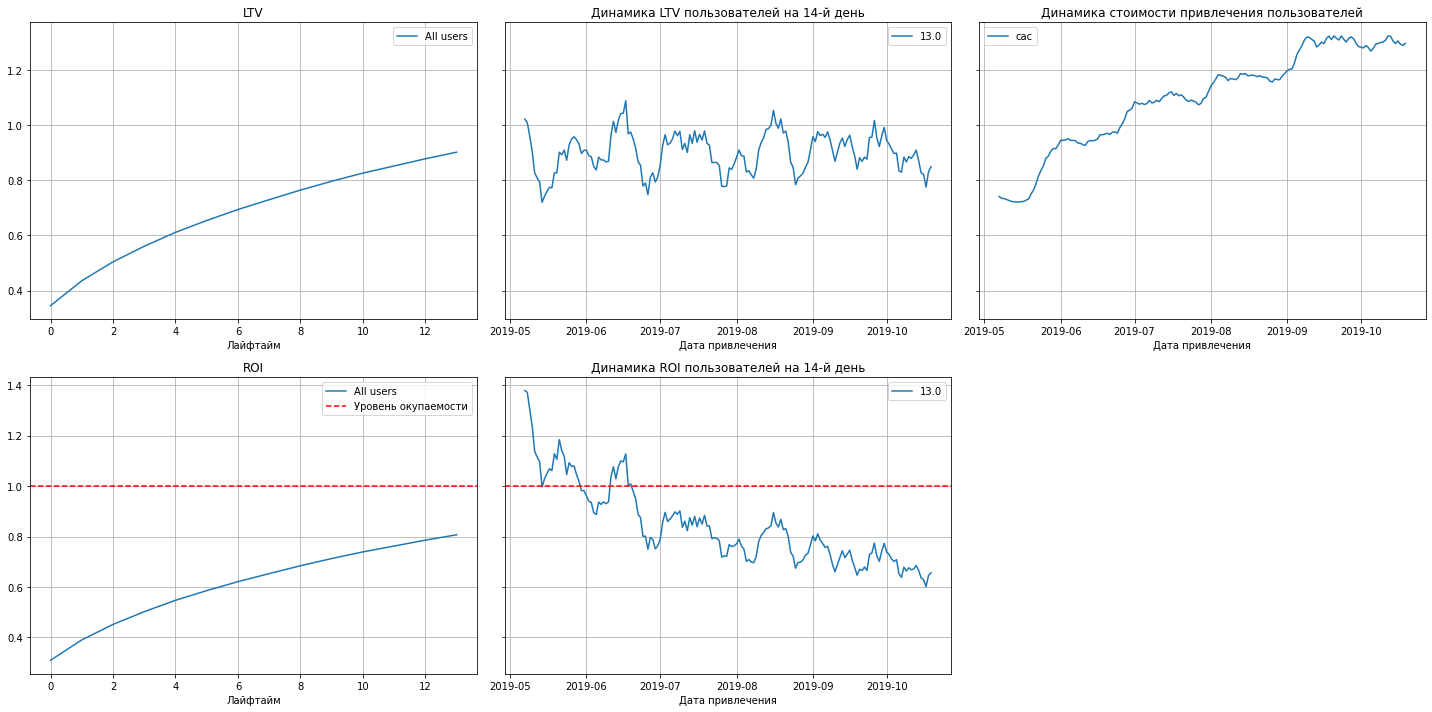

In [ ]:
#графиков LTV и ROI, а также графики динамики LTV, CAC и ROI.
# считаем LTV и ROI
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_no_org, orders, observation_date, horizon_days
)

# строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days)

<div class="alert alert-info"> <b>Вывод</b>:
    
1) LTV в порядке, он растёт, в динамике достаточно стабилен;
    
2) Стоимость привлечения одного клиента (CAC) на протяжении всего рассматриваемого периода росла, вероятно произошло значительное увеличение рекламного бюджета;
    
3)Реклама не окупается. ROI в конце второй недели - чуть больше 80%, в динамике "точка невозврата" возникла в середине июня - с этого момента затраты на рекламу перестали окупаться. </div>

<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
    
Всё так. Но тут любопытно, что LTV стабилен, а `CAC` растёт, вероятно это проявление роста конкуренции на канале.</div>

<div style="border:solid green 2px; padding: 20px"> Далее попробуем выяснисть, какой фактов оказал внияние на то, что потраченные на рекламу деньги не окупились. Для этого проанализируем окупаемость рекламы с разбивкой по: 1)устройствам, 2)странам, 3)рекламным каналам</div>

###  Окупаемость рекламы с разбивкой по устройствам

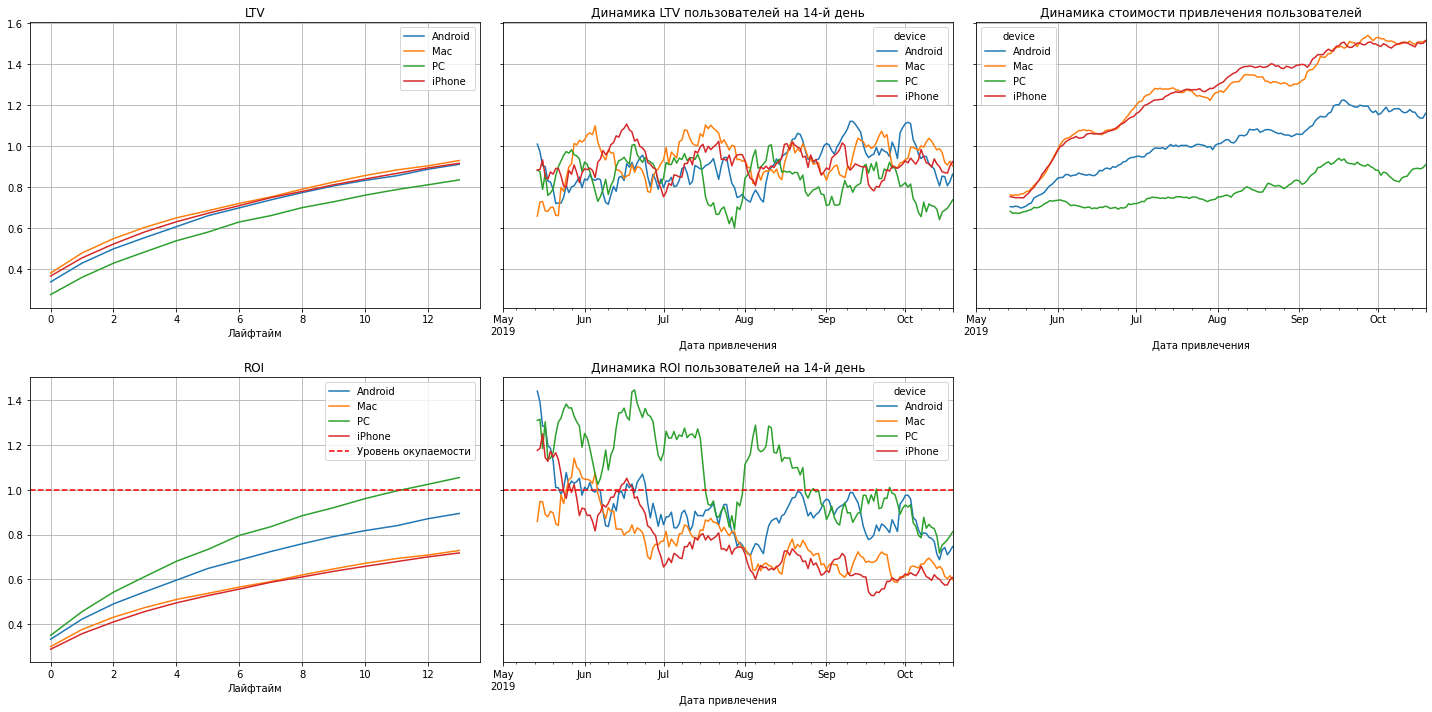

In [ ]:
# смотрим окупаемость с разбивкой по устройствам
#разаём функции значение параметра dimensions = ['device']
dimensions = ['device']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_no_org, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

<div class="alert alert-info"> <b>Вывод</b>:
    
1) Самыми прибыльными клиентами являются пользователи Mac, IPhone, Android, их LTV (средняя накопительная выручка) к концу второй недели выше 0.9 y.e.
    
2) Cамая высокая cтоимость привлечения одного клиента по устройствам Mac и IPhone, в рассмотриваемом периоде CAC постоянно  росла и достигла 1.5 у.е. Начиная с июня, CAC по этим устройствам превышает их LTV на конец второй недели. В динамике CAC пользователей с Mac и IPhone стал выше их LTV в середине июня. Самая низкая стоимость привлечения одного клиента у PC - 9 у.е; за исследуемый период по всем устройствам расходы на рекламу имели тренд к росту;
    
3) Окупаемость зависит от CAC. Из всех источников к концу второй недели окупается только PC: ROI чуть меньше 110%; при этом в динамике мы видими, что с конца августа ROI PC опустился ниже уровня окупаемости и стал равен 70%; в целом за последние два месяца (сентябрь-октябрь) не окупился никто. Клиенты, использующие Mac, IPhone, Android перестали окупаться в июне. По всем устройствам за рассматриваемый период заметен тренд на ухудшение показателей</div>

<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
    
Хочу акцентировать твоё внимание на способе решения в данном случае комплексной задачи - неокупаемость маркетинга. Мы эту составную проблему раскладываем на частные причины, декомпозируем весь трафик по странам, устройствам, регионам и ищем где конкретно и в какой момент случилась проблема.
</div>

### Окупаемость рекламы с разбивкой по странам

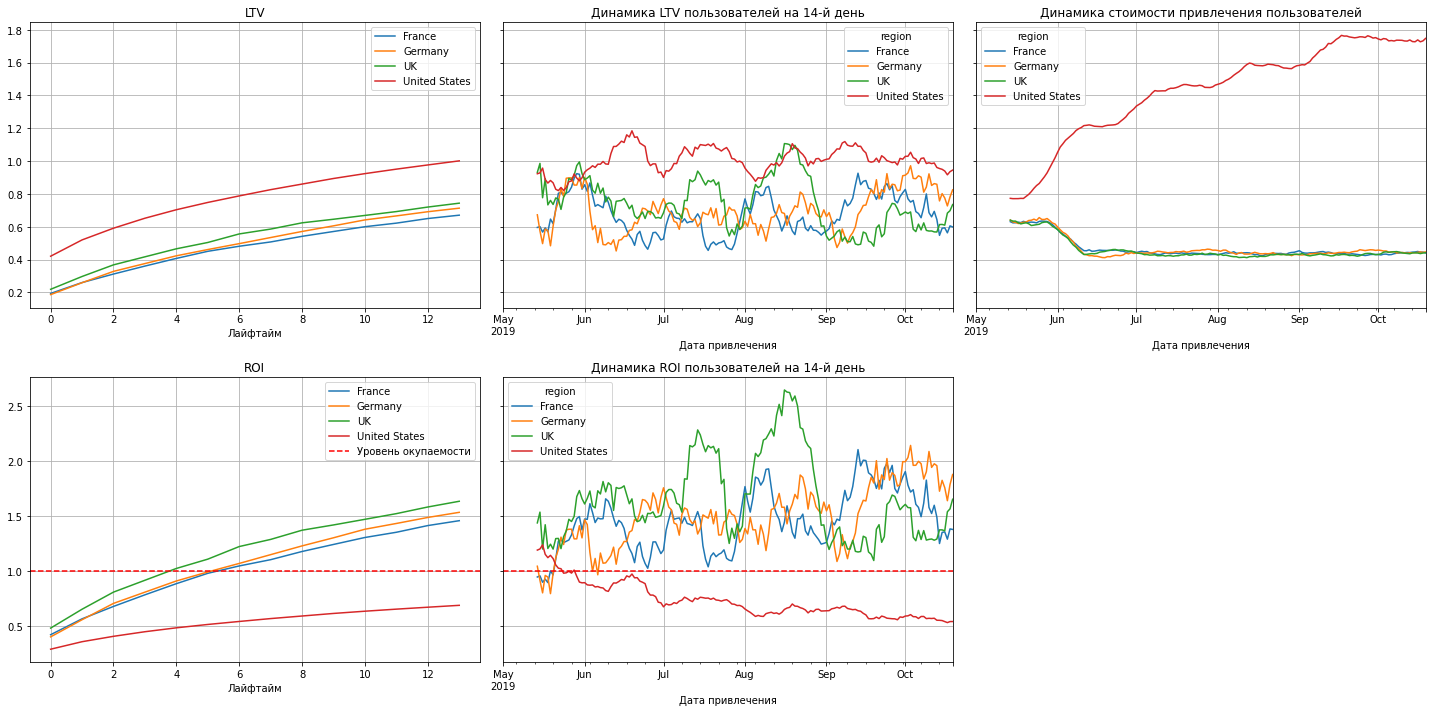

In [ ]:
# смотрим окупаемость с разбивкой по странам

dimensions = ['region']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_no_org, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

<div class="alert alert-info"> <b>Вывод</b>:
    
1) Самый высокий LTV у клиентов из США - 1 у.е., в динамике он принимает значения больше и стабильно выше остальных стран; на втором месте LTV пользователей из Великобритании - в августе LTV на конец второй недели у клиентов из Великобритании был таким же высоким, как и у клиентов из США. Подобный резкий рост заметен и у показателя ROI по Великобритании - середина июля и август, причем мы видим, что это никак не связано с расходами на рекламу - стоимость привлечения в эти периоды не изменялась и оставалась на уровне 0.4 у.е.

2) Окупаемость к концу второй недели произошла у всех стран - на 150%, кроме США. Траты на рекламу для клиентов из США не окупились;

3) Стоимость привлечения с конца мая по всем странам кроме США снизилась до 4 центов и стала ниже чем LTV в динамике на конец второй недели - эти рекламные расходы явно окупились. Однако у США же картина обратная - стоимость привлечения выросла больше чем в 2 раза и достигла почти что 1,8 долларов. CAC по клиентам из США также стал выше чем LTV с середины июня, тот же окончательный тред на снижение прослеживается и у ROI.

Итак, по графикам мы видим, что наращивание расходов на рекламу происходило для пользователей из США, что логично - эти клиенты приносят нам больше денег. Однако траты на рекламу не принесли желаемого результата - рост трат на рекламу никак не привёл к желаемому результату - клиенты не стали тратить больше денег и реклама не окупилась.

Возможно дело в неверно выбранном канале привлечения?</div>


<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
   
Абсолютно верный вывод, каналы, работающие на `US` не столь удачны, особенно крупные
</div>

### Окупаемость рекламы с разбивкой по источникам привлечения

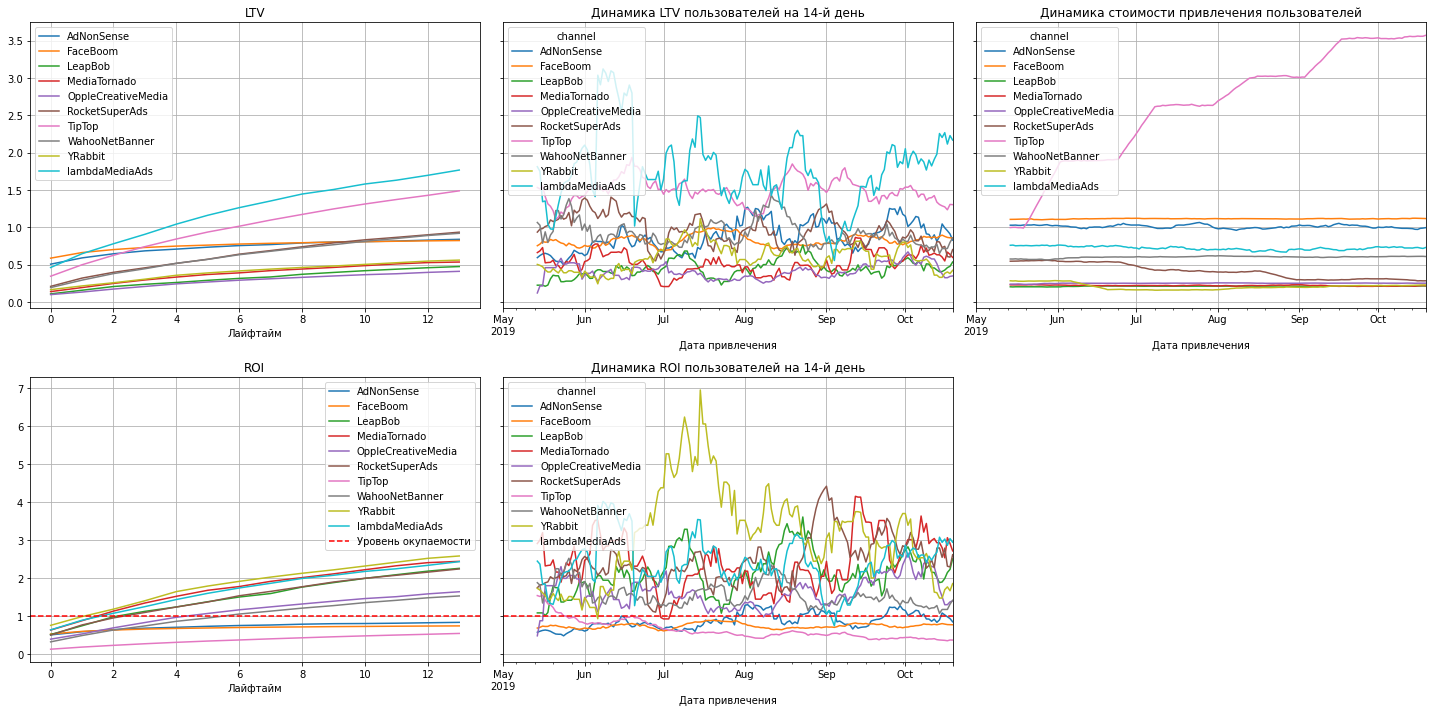

In [ ]:
# смотрим окупаемость с разбивкой по источникам привлечения

dimensions = ['channel']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_no_org, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

<div class="alert alert-info"> <b>Вывод</b>:
    
1) Лидеры LTV: 'lambdaMediaAds' и 'TipTop' 1.7 и 1.5 доллара соответственно; в динамике картина та же, лишь в первой половине сентября LTV 'TipTop' стало выше;
    
2) При этом CAC у 'lambdaMediaAds' был стабильным и в динамике остался ниже LTV, а вот у 'TipTop' с июня превысил LTV на конец второй недели и продолжил стремительно расти;
    
3) Окупились все рекламные источники кроме: AdNonSense и FaceBoom(примерно 80% окупаемость). Аутсайдер - TipTop (окупилось примерно на 55%). По графику динамики ROI показатель по каналу TipTop стал ниже уровня окупаемости в конце мая.</div>

<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
    
Чудеса декомпозиции,  отличный подход, который всегда приведёт к успеху, разобрались с LTV И ROI, получили явную проблему в US и TIp Top с Faceboom, при учете, что US - страна с наибольшим количеством пользователей, а Tip TOp и FaceBoom - крупнешие каналы для нас это важные находки, дальше с которыми стоит работать</div>


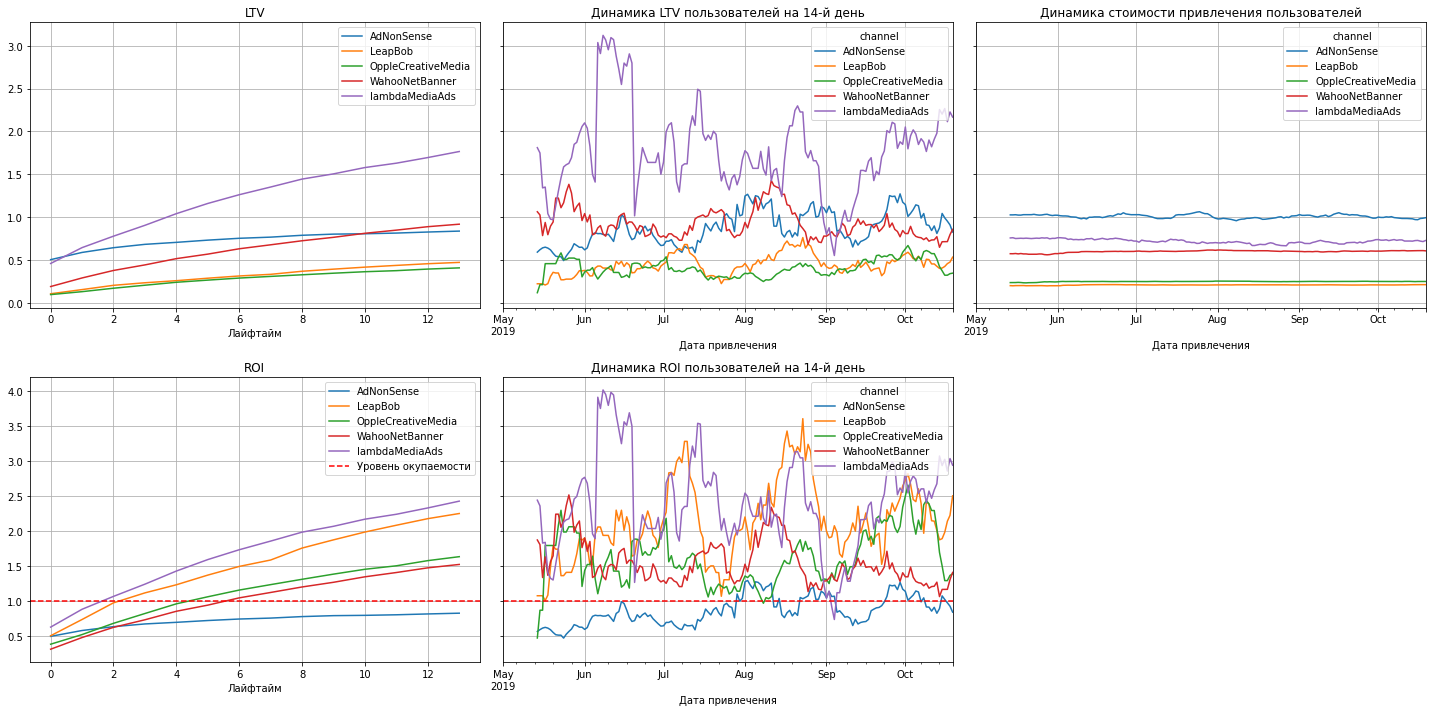

In [ ]:
#Окупаемость по Европейскому рынку:

profiles_eu = profiles.query('region != "United States" and channel != "organic"')

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_eu, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

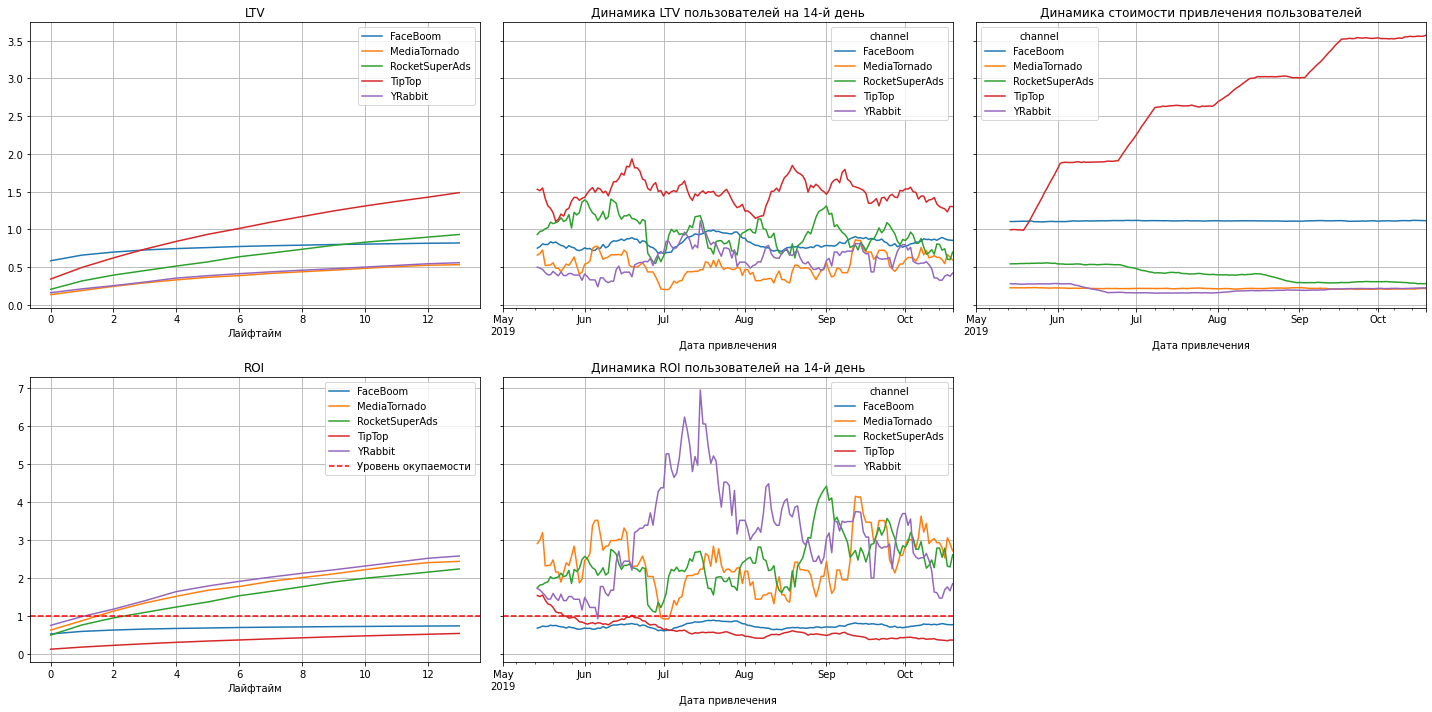

In [ ]:
#Окупаемость по американскому рынку:

profiles_us = profiles.query('region == "United States" and channel != "organic"')
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_us, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

<div class="alert alert-info"> <b>Вывод</b>:
Итак, предположение о причине убытков компании подтвердилось - большая часть расходов на рекламу ушла на каналы, по которым затраты на клиентов совершенно не окупились. Из них наихудшая картина по TipTop (55% окупаемость). Стоит отметить также, что динамика стоимости привлечения пользователей на европейском рынке стабильнее, чем н американском.
    
За рассматриваемый период на европейском рынке лучшие показатели были по каналу lambdaMediaAds - окупаемость почти на 250% к концу второй недели. На американском рынке лучший показатель окупаемости у канала YRbbit - 260%; но интересно выглядит и канал RocketSuperAds - он третий по окупаемости (220%), но стоимость привлечения пользователей через него намного ниже, чем через TipTop или FaceBoom, а при этом LTV выше и FaceBoom и YRbbit.

</div>

<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
    
Браво, отличный разбор)

### Конверсия и удержание пользователей

#### Конверсия и удержание пользователей: разбивка по рекламным источникам

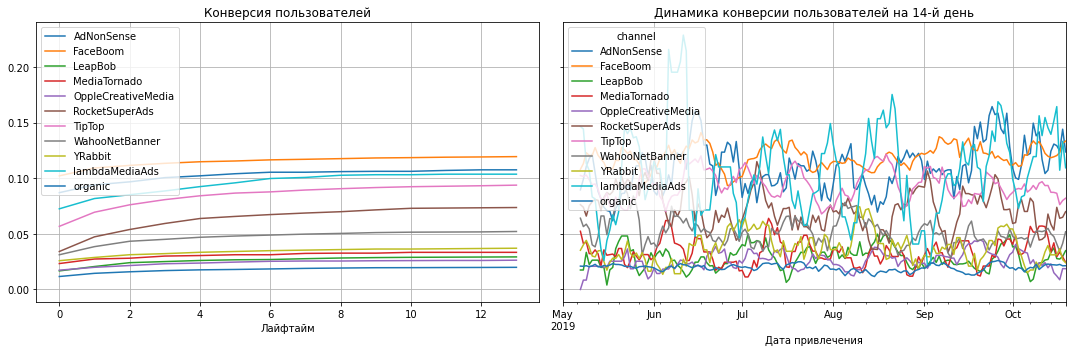

In [ ]:
# смотрим конверсию с разбивкой по источникам; для расчётов берём все каналы привлечения, в тч organic

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

<a id="iiii"></a>

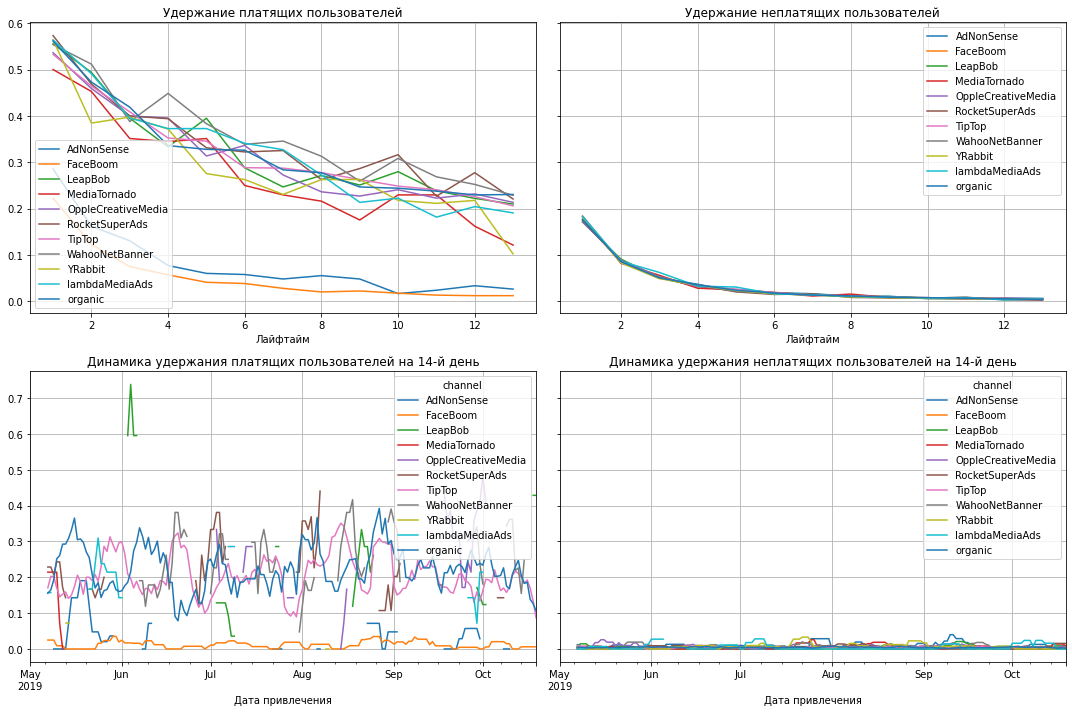

In [ ]:
# смотрим удержание

retention_raw, retention_grouped, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days, dimensions=dimensions
)

plot_retention(retention_grouped, retention_history, horizon_days)

<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
    
Обрати внимание, что удержание неплатящих пользователей из разных каналов, стран, платформ ровное, а удержание платящих очень отличается, как считаешь почему так?
</div>

<div class="alert alert-info"> <b>Вывод</b>: Хуже всего конверсия у OppleCreativeMedia, LeapBob и Organic; лучше всего - у FaceBoom, AdNonSense и  lambdaMediaAds. Удеражание лучше у каналов RocketSuperAds, WahooNetBanner и Organic, хуже всего у каналов, на рекламу которых потрачено 33% всех затрат - FaceBoom и AdNonSense.</div>

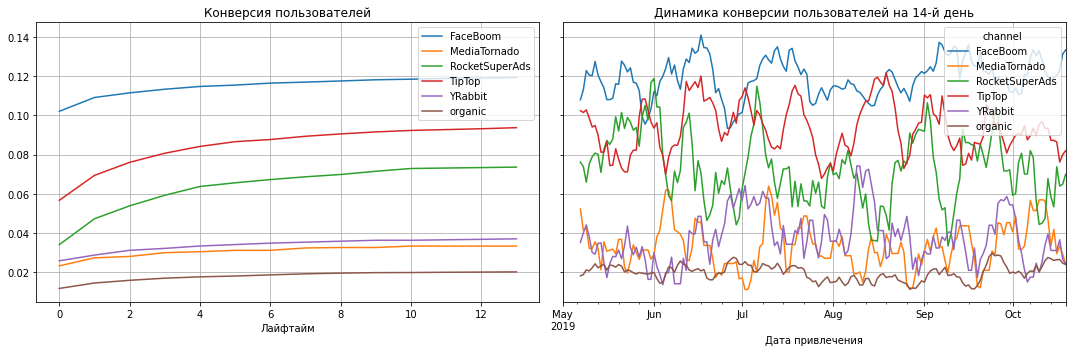

In [ ]:
# Американский рынок:
profiles_usa = profiles.query('region == "United States"')
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles_usa, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

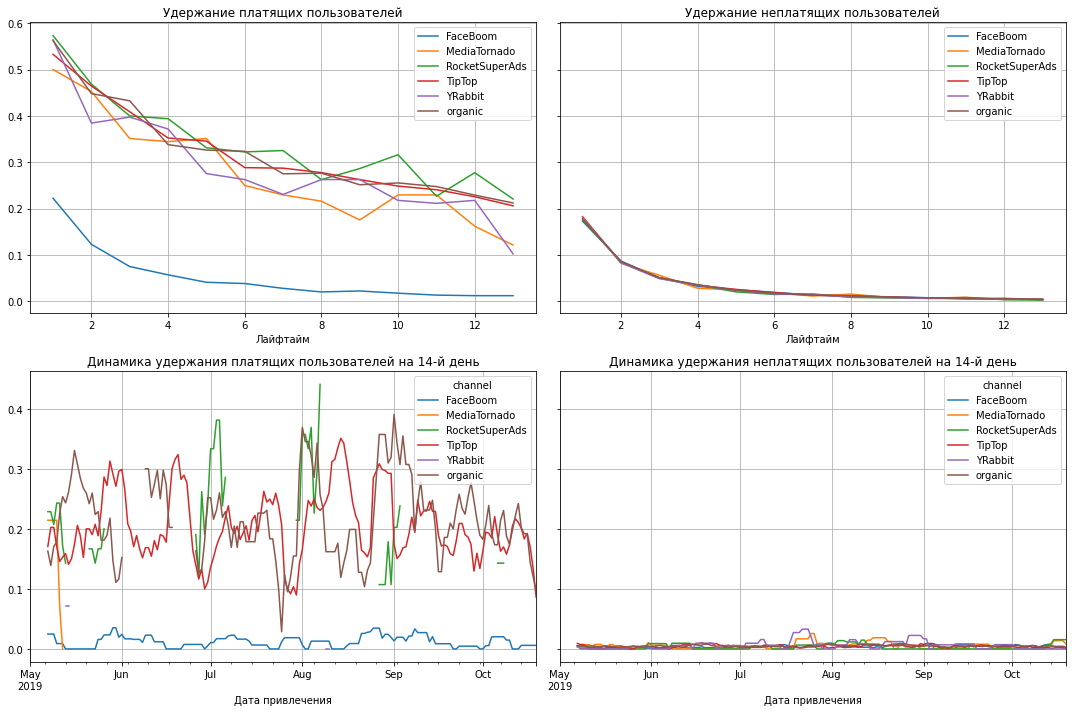

In [ ]:
retention_raw, retention_grouped, retention_history = get_retention(
    profiles_usa, visits, observation_date, horizon_days, dimensions=dimensions
)

plot_retention(retention_grouped, retention_history, horizon_days)

<div class="alert alert-info"> <b>Вывод</b>: Самая высокая конверсия и самое низкое удержание на американском рынке у канала FceBoom. На втором по конверсии месте - TipTop, удержание пользователей по нему неплохое, на уровне клиентов, которые нашли приложение самостоятельно; вероятно по данному каналу расходы на рекламу не окупились ввиду высоких тарифов. Перспективно выглядит канал RocketSuperAds - неплохая конверсия и удержание. </div>

In [ ]:
#Европейский рынок:
profiles_eu = profiles.query('region != "United States"')

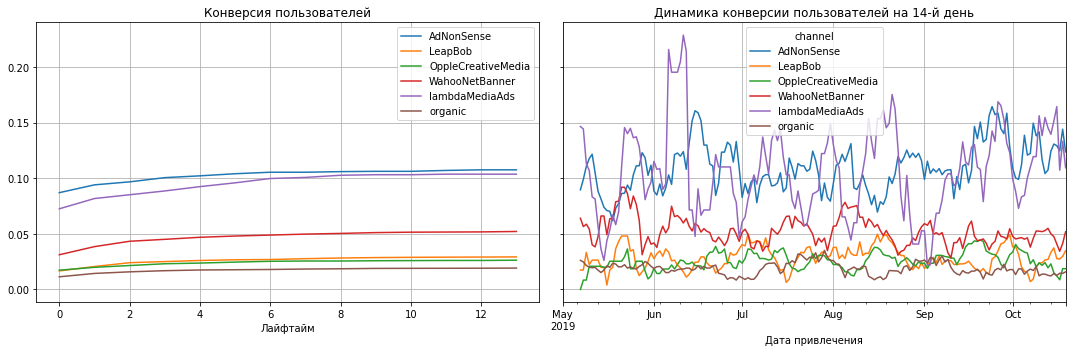

In [ ]:
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles_eu, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

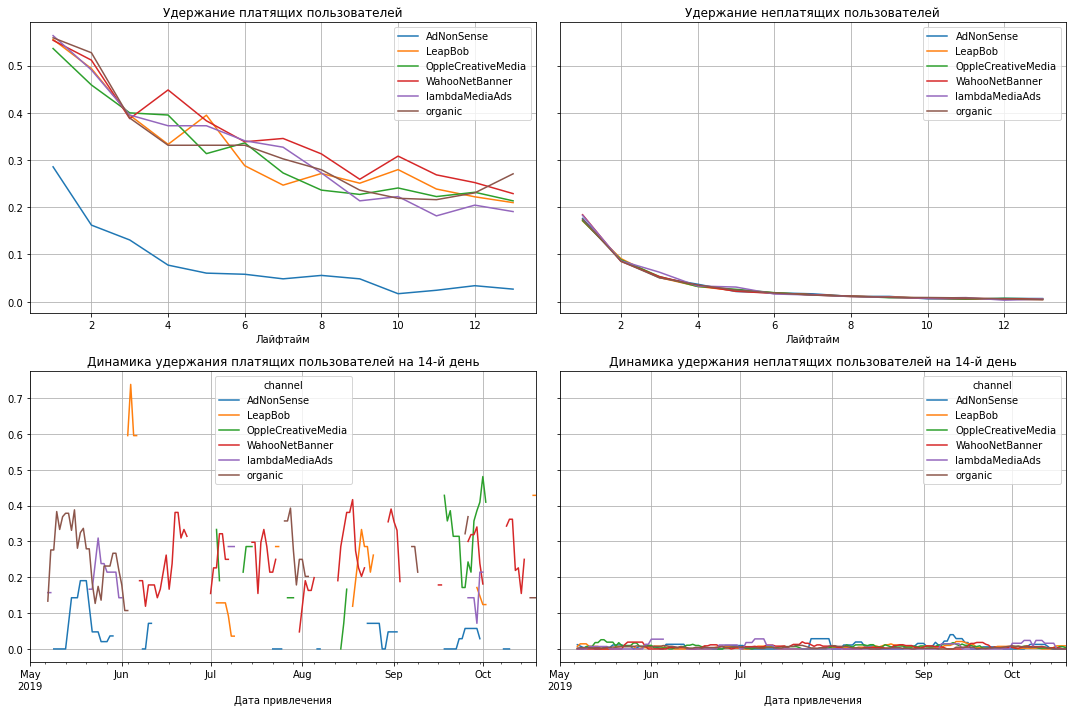

In [ ]:
retention_raw, retention_grouped, retention_history = get_retention(
    profiles_eu, visits, observation_date, horizon_days, dimensions=dimensions
)

plot_retention(retention_grouped, retention_history, horizon_days)

<div class="alert alert-info"> <b>Вывод</b>: На европейском рынке хуже всего удерживается AdNonSense. Наиболее перспективно выглядят показатели по каналу lambdaMediaAds</div>

#### Конверсия и удержание пользователей: разбивка по регионам

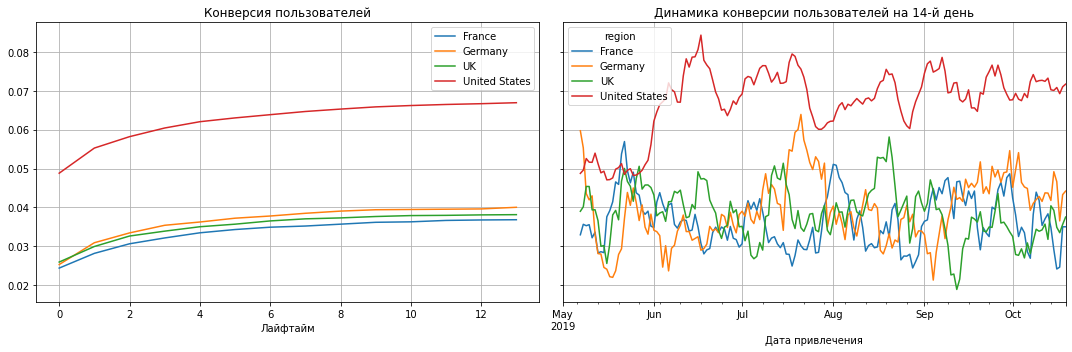

In [ ]:
#конверсия
dimensions = ['region']
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

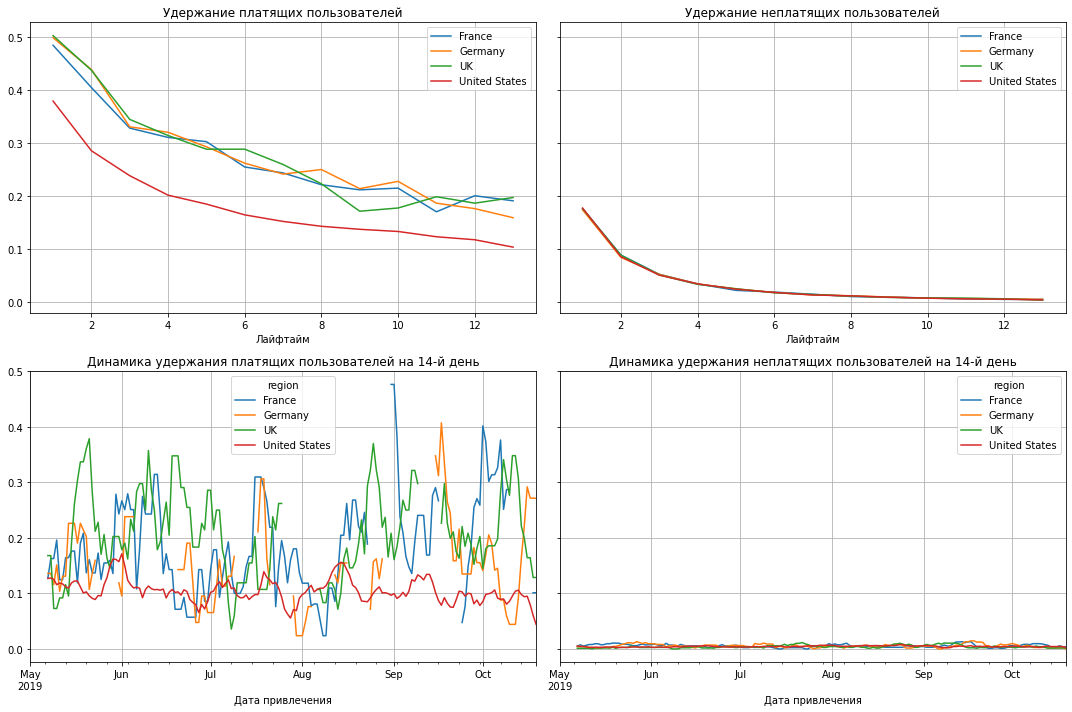

In [ ]:
# смотрим удержание

retention_raw, retention_grouped, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days, dimensions=dimensions
)

plot_retention(retention_grouped, retention_history, horizon_days)

<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
    
Существенная проблема - плохое удержание в US, можно было подробнее посмотреть на всех ли каналах, которые приводят трафик в US, такая ситуация, анонсирую, что два самых крупных канала приводят трафик только из US, если захочешь, можешь поисследовать. Любопытно, что динамика конверсии `US` становится с течением времени не такой волатильной. </div>

<div class="alert alert-info"> <b>Вывод</b>: Стабильно хуже удерживаются пользователи из США</div>

#### Конверсия и удержание пользователей: разбивка по устройствам

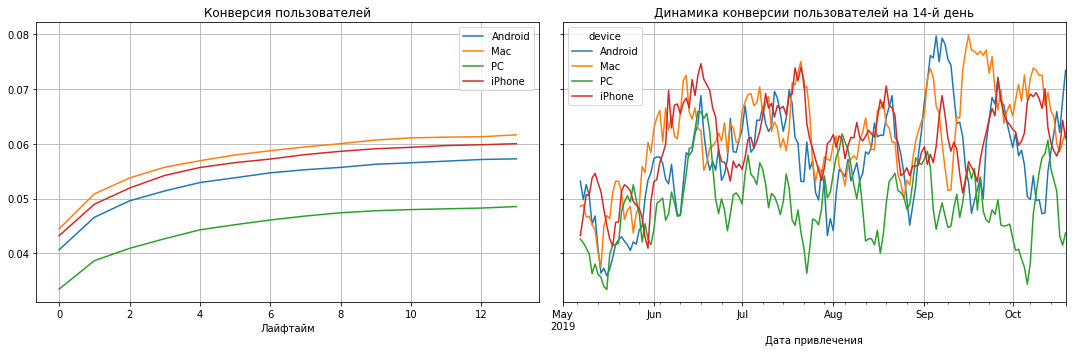

In [ ]:
dimensions = ['device'] #ничего особенного, можно и убрать
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

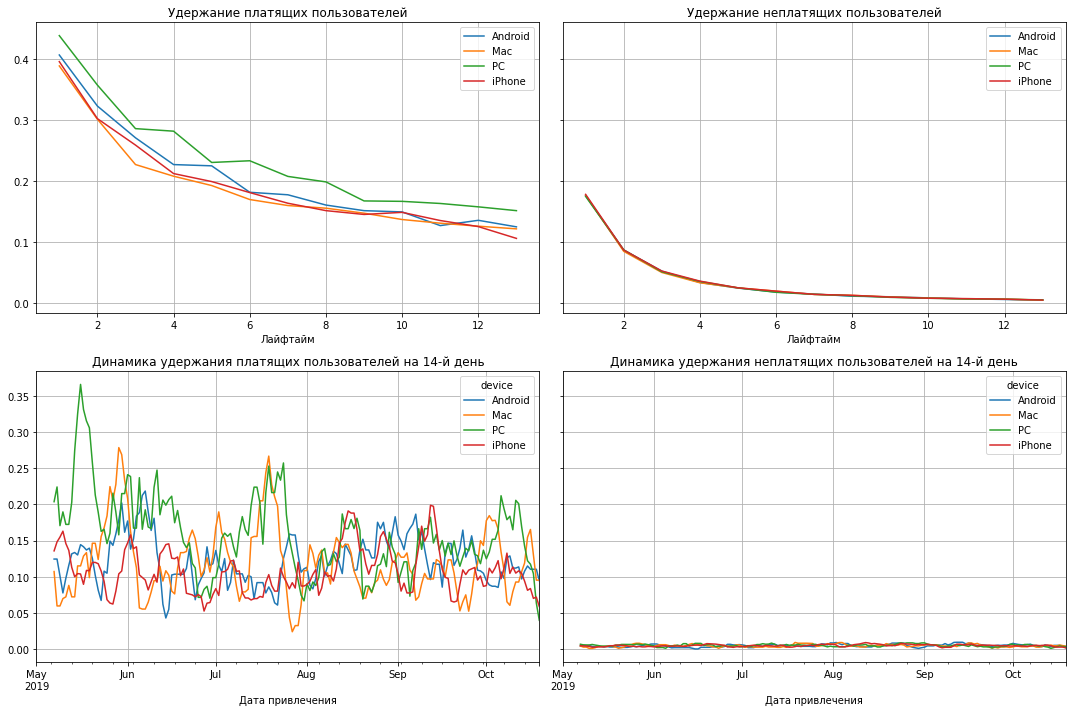

In [ ]:
# смотрим удержание с разбивкой по устройствам

retention_raw, retention_grouped, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days, dimensions=dimensions
)

plot_retention(retention_grouped, retention_history, horizon_days)

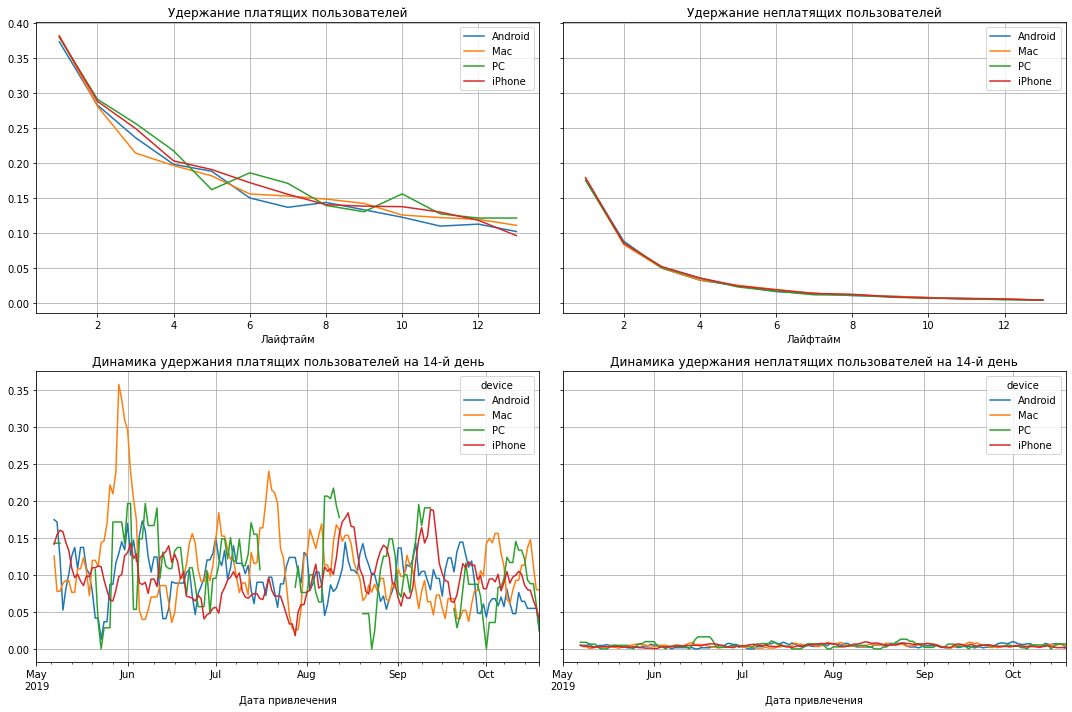

In [ ]:
#Американский рынок
retention_raw, retention_grouped, retention_history = get_retention(
    profiles_usa, visits, observation_date, horizon_days, dimensions=dimensions
)

plot_retention(retention_grouped, retention_history, horizon_days)

<div class="alert alert-info"> <b>Вывод</b>: Самое высокие показатели удержания платящих пользователей - по PC, рекламные затраты по которому окупились (в отличии от остальных устройств). Хуже всего удерживаются пользователи устройств системы iOS, как мы помним, в основном это пользователи из Америки, причем в большей степени - пользователи iPhone. По графику динамики удержания мы видим, что как раз пользователи IPhone удерживаются чуть хуже.

В целом можно сделать вывод, что ставка на высокую конверсию по определённым параметрам (Страна - США, канал, устройства системы iOS) оказалась ошибочной. Не смотря на высокую конверсию или высокую ценность клиента, выбранные параметры оказались провальными:
1) Ставка на пользователей из США - плохое удержание;
2) Ставка на каналы, привлекающие пользователей из США: дорого (TipTop) при средних результатах по конерсии и удержанию или же FaceBoom, у которого плохое удержание при условии того, что на рынке имеются более дешевые и лучше удерживающие рекламные источники (при чуть менее высокой конверсии - RocketSuperAds)</div>

 <div class="alert alert-info"> <b>Выводы по разделу </b>:
    
1) Реклама на привлечение пользователей в целом не окупается;
    
2) Не окупается реклама по США, рекламные каналы AdNonSense (европейский рынок), FaceBoom и аутсайдер - TipTop (американский рынок). Хуже всего окупаются устройства на ОС iOS (Mac, iPhone)
    
3) Мы видим, что в большинстве случаев (страна, канал, устройство)  проблема связана с низким уровнем удержания платящих пользователей. При этом главная проблема - по пользователя из США, которые удерживаются в 2 раза хуже, чем пользователи из Европы, что непосредственно влияет среднюю сумму денег, которую клиент приносит компании. С учётом высоких рекламных расходов и возникает проблема с окупаемостью. Пользователи из США, использующие в основном Mac и iPhone и привлеченные через канал FaceBoom - не окупаются и не удерживаются.  Это может быть связано как с техническими ошибками, так и не удобством использования и совершения оплаты в приложении для iOS.  
    </div>
    

<div class="alert alert-success">
<b>Комментарий ревьюера :</b>☀️
   
Очень подозрительно выглядит удержание `FaceBoom`, предположу, что здесь проблема в мотивированности трафика, возможно `FaceBoom` нагоняет пользователей, которые должны заплатить, а за это в другой игре они получают какой-то бонус)

</div>

## Вывод итоговый

<div class="alert alert-info">
    
Проблема с окупаемостью довольно-таки комплексная: пользователей из США не окупаются и плохо удерживаются, при этом в основном используют наше приложение (и совершают покупки в нём) на устройствах ОС iOS (Mac, iPhone), по которым мы также видим удержание платящих пользователей ниже прочих девайсов; на это накладывается также проблемы с каналами привлечения пользователей - вероятно большая конверсия побудила к большим вложениям именно в американский рынок и рекламу для него. Это мы видим из объёмов пришедшихся на каналы FaceBoom и TipTop затрат (82% от всех затрат на рекламу); также мы видим, что данные действия не привели к желаемому результату, однако по разным причинам. Проблема с рекламным источником FaceBoom связана с низким удержанием пользователя, проблема с TipTop на наш взгляд - с дорогим тарифом и ставкой на одного "игрока", который показал в итоге средние результаты. Если обратить внимание на временной отрезок, то проблемы с окупаемостью возникли на 22 неделе/с начала июня.
    
На американском рынке хуже удержание пользователей с мобильными устройствами - iPhone и Android.
    
Стоит отметить также, что динамика стоимости привлечения пользователей на американском рынке менее стабильна, чем на европейском. На европейском рынке у нас в основном пользователи с Android и PC; При этом по PC вышло хорошее удержание, стабильный LTV; хотя канал для привлечения европейских клиентов был выбран неудачно - пользователи с AdNonSense плохо удерживались.  

За рассматриваемый период на европейском рынке лучшие показатели были по каналу lambdaMediaAds - окупаемость почти на 250% к концу второй недели, а также высокая конверсия и хорошое удержание. На американском рынке лучший показатель окупаемости был у канала YRbbit - 260%; но интересно выглядит и канал RocketSuperAds - он третий по окупаемости (220%), но стоимость привлечения пользователей через него намного ниже FaceBoom и TipTop, конверсия лишь на 0,02 п.п. ниже чем у TipTop, но удержание выше.


Можно сделать следующие рекомендации для отдела маркетинга:
1) Остановить использование убыточных каналов (AdNonSense и FaceBoom) - они
    
2) Выбрать для привлечения пользователей альтернативные рекламные каналы: lambdaMediaAds для европейского рынка и RocketSuperAds для американского, TipTop явно переоценён    
3) Осторожнее подходить к вопросу распределения рекламных бюджетов и диверсифицировать риски.     
    
</div>

<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
    
* Отличная работа, у меня нет критических замечаний, быть может у тебя имеются вопросы. Отмечены верные шаги по улучшению ситуации в закупке, ещё считаю важной рекомендацией - чаще обращать внимания на показатели маркетинга, а то очень похоже, что маркетинговый отдел долгое время сжигал деньги не очень эффективно). В работе я оставил некоторое количество мелких рекомендаций от себя, надеюсь ты из них вынесешь что-то для себя и будешь активно применять в будущих проектах и работе.) Рекомендую поработать над оформлением теста `markdown` разметкой и особенно распространить оглавление, его можно сделать более подробным, что упростит навигацию по проекту, сейчас твоё оглавление выглядит так ![image.png](attachment:image.png)
    
* О том, как **форматировать текст** в Markdown ячейке или как добавлять ссылки, ты можешь узнать [тут](https://sqlbak.com/blog/jupyter-notebook-markdown-cheatsheet) и [вот тут](https://medium.com/analytics-vidhya/the-ultimate-markdown-guide-for-jupyter-notebook-d5e5abf728fd).

    
* Сейчас работаю аналитиком в отделе закупки игровой компании и US это действительно наибольший рынок, ему достается процентов 30-40 всего трафика, да набор каналов существенно шире, но US доминирует в этом плане. Конечно у нас перед глазами набор дашбордов, которые позволяют контролировать множество всяких метрик, но периодически бывает всякое, конечно же масштабирование канала, который становится всё хуже и хуже - сомнительная идея, а оптимизации происходят существенно чаще, по некоторым каналам раз в неделю, а по некоторым и ещё чаще). Жду повторной отправки проекта
    
</div>

<div class="alert alert-info"> <b>Комментарий студента (Алина):</b>
    
<b>Пётр, спасибо</b> за ссылки, особенно за style.format спасибо, очень удобно! Оформление не очень люблю, много времени уходит, но статья была полезной! И за пояснения остальных моментов, мне было не легко, не зная особо маркетинг, таргет и тэдэ строить гипотезы по графикам, оставалось только описывать цифры и тренды ((
   
  
<b>[Вопрос 1](#i) </b>    
<blockquote> <div class="alert alert-success">Вот здесь бы очень ценным было разбиение каналов по странам, удалось бы определённые закономерности выявить)</div> </blockquote>    
<b>Добавила разбивку.</b> По Америке стало понятно, что канал на который мы больше денег потратили в 2 раза меньше платящих пользователей привёл, но это уже постфактум, когда я уже видела график затрат на рекламу.
Также видно каналы, которые приводят меньше платящих пользователей, чем по organic.
<b>О каких закономерностях ты говорил?</b>

<b>[Вопрос 2](#i)</b>
Увидела что по европейскому рынку лучше приходят платящие пользователи через WahooNetBanner, а из аутсайдеров -  lambdaMediaAds, хотя он по ltv лидер, окупается, третий по конверсии - что меня смутило - рекомендовать ли его в итоге или нет?
    

 <b>Маркетинг</b>  
    
<b>[Вопрос 3](#ii)</b>
не слышала еще про такую опцию (ниже). Гугл тоже результатов пока не дал, можешь подсказать как, что за параметр? :
    
<blockquote> <div class="alert alert-success"> Для того, чтобы внимательнее изучить колебания затрат по каналам можно строить несколько графиков по размеру значений, здесь это не так критично, но вообще не особо понятно, как там дела с бюджетом всех каналов кроме двух крупнейших </div> </blockquote>
    
    
 <b>[Вопрос 4 - LTV стабилен, а CAC растёт](#iii)</b>
    <blockquote> <div class="alert alert-success"> Всё так. Но тут любопытно, что LTV стабилен, а CAC растёт, вероятно это проявление роста конкуренции на канале.</div> </blockquote>
    
Я заметила эту особенность, но не знала чем объяснить. <b>Что ты имел ввиду, говоря о росте конкуренции? Это значит что так мы видим общую конкуренцию среди рекламных каналов в нашей выборке?

По остальным графикам видно, что эта ситуация характерна для определённой страны (сша), определённого канала (типтоп), для устройств не так ярко но всё же.</b>
    
<b>[Вопрос 5 - Конверсия и удержание пользователей:](#iiii)</b>
<blockquote> <div class="alert alert-success"> Обрати внимание, что удержание неплатящих пользователей из разных каналов, стран, платформ ровное, а удержание платящих очень отличается, как считаешь почему так? </div> </blockquote>
    
Заметила это, <b>может быть это отображение каких-то действий пользователя – допустим через какой-то рекламный баннер он получил код на временное бесплатное пользование?</b> Кроме этого ничего не придумывается  
Еще обратила внимание что <b>по двум каналам удержание практически такое же как по не платящим</b>. По каким причинам такое случается? Нже твоя цитата, она об этом?
<blockquote> <div class="alert alert-success"> Очень подозрительно выглядит удержание FaceBoom, предположу, что здесь проблема в мотивированности трафика, возможно FaceBoom нагоняет пользователей, которые должны заплатить, а за это в другой игре они получают какой-то бонус) </div> </blockquote>    
    


</div>

<div class="alert alert-success">
<b>Комментарий ревьюера v2:</b>☀️
   

Смешно про не Пётр, прости, Алина...)  
    
1. О закономерностях, что каналы в Европе и в США отличаются, общий только `organic`)
2. При рекомендации канала лучше ориентироваться на его `ROI` и стабильность этого параметра, при этом для маленьких каналов лучше считать его более крупными когортами, недельными или даже месячными, чтобы метрика была не столь волатильной.
3. Можно построить несколько графиков получив срез по каналам при помощи `query`, через спринт расскажут про библиотеку `plotly`, она позволяет строить интерактивные графики, как раз в данном случае она была бы очень уместна, позволила бы убирать некоторые каналы, чтобы внимательнее анализировать с меньшим бюджетом, вот [ссылка](https://habr.com/ru/post/502958) если интересено
4. Если нам достаётся пользователь с одним и тем же `LTV` за всё большие деньги, то вероятнее для нас конкуренция на этом канале становится всё выше, технически между объявлениями ведь устраивается аукцион, и например сначала надо было потратить сто условных единиц и это удавалось, так как мест показа рекламы много, а потом растёт бюджет и может случаться такое, что аудитории на канале крайне малое количество и ставки на неё начинают расти. надеюсь что-то прояснилось, можно погуглить о рекламных аукционах, вот [примерчик](https://netpeak.net/ru/blog/auktsion-reklamy-v-facebook-vse-o-chem-vy-stesnyalis-sprosit/) быстро нашёл. А вообще как раз рост `CAC` на штатах, типтоп, подсказывает, что они связаны))
5. Да, цитатта про `FaceBoom` и предположение о мотивированности трафика как раз об этом). Здорово, что удалось обратить твоё внимание на волатильность. При анализе частенько бывает, что величина волатильна, но это не из-за её природы, а из-за того, что наблюдений мало, и каждое отдельное наблюдение существенно влияет на оценку  

    
    
Приятна твоё рвение, вопросы, желаю тебе удачи, понравилось с тобой работать, всего доброго)

<b>пысы: если что, я не Влад, я - Алина :D.
    
  если ты тоже не Пётр - то без обид, я из шапки имя копировала) </b>